# Week 4 Lab: Linear Models

AIE683 Machine Learning, Hacettepe University.

Two real prediction problems run through this lab:

* **What is this house worth?** Automated valuation models estimate sale prices for lenders, insurers and tax assessors. We use the Ames, Iowa housing data (2,930 sales, 80 features).
* **Is this tumour malignant?** The Wisconsin breast cancer data (569 biopsies, 30 measurements) is a diagnostic problem where calibrated probabilities matter as much as the predicted label.

Contents

1. Regression on Ames: preprocessing pipeline, skewed targets, `LinearRegression` vs. `Ridge`, tuning `alpha`
2. **Try it 1**: a small Ames competition
3. Regularization with few samples (triazines): Ridge, Lasso, Elastic Net
4. Logging a regularization path to MLflow
5. Classification: logistic regression, linear and kernel SVMs, multiclass
6. **Try it 2**: predict, then run
7. Comparing linear and kernel classifiers with MLflow

Cells marked `# TODO` are for you. They run as provided (with a baseline), so you can execute the notebook top to bottom at any time. Runtime is about 2-3 minutes.

In [1]:
%matplotlib inline
import logging
import warnings
from time import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import (TransformedTargetRegressor, make_column_selector,
                             make_column_transformer)
from sklearn.datasets import fetch_openml, load_breast_cancer, load_digits, load_iris
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (ElasticNet, Lasso, LinearRegression, LogisticRegression,
                                  LogisticRegressionCV, Ridge)
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import (GridSearchCV, KFold, StratifiedKFold, cross_val_score,
                                     train_test_split)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC, LinearSVC

SEED = 0
np.random.seed(SEED)
np.set_printoptions(suppress=True, precision=3)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.datasets")
warnings.filterwarnings("ignore", message="IProgress not found")

## 1. Regression on Ames housing

We fetch the data from OpenML (`ames_housing`, id 43926). Following the dataset author's advice we drop the few houses with more than 4000 sq ft of living area (partial sales that behave differently).

In [2]:
ames = fetch_openml(data_id=43926, as_frame=True)
X, y = ames.data, ames.target
keep = X['Gr_Liv_Area'] <= 4000
X, y = X[keep], y[keep]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2)
print(X_train.shape, "numeric columns:", X_train.select_dtypes(include='number').shape[1])

(2193, 80) numeric columns: 34


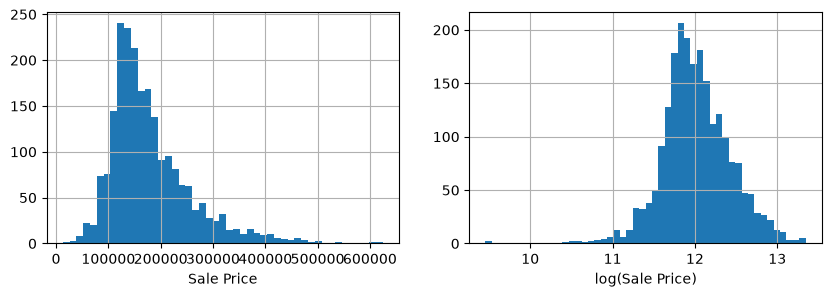

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
y_train.hist(bins='auto', ax=axes[0])
axes[0].set_xlabel('Sale Price')
np.log(y_train).hist(bins='auto', ax=axes[1])
axes[1].set_xlabel('log(Sale Price)');

One pipeline handles both column types: categorical columns are one-hot encoded, numeric ones imputed and scaled. Scaling matters for penalized models: the penalty treats all coefficients alike, so features must be on comparable scales.

In [4]:
cat_preprocessing = make_pipeline(SimpleImputer(strategy='constant', fill_value='NA'),
                                  OneHotEncoder(handle_unknown='ignore'))
cont_preprocessing = make_pipeline(SimpleImputer(), StandardScaler())
preprocess = make_column_transformer(
    (cat_preprocessing, make_column_selector(dtype_include=['object', 'category'])),
    remainder=cont_preprocessing)

def log_target(model):
    return TransformedTargetRegressor(model, func=np.log, inverse_func=np.exp)

for name, model in [("LinearRegression", LinearRegression()),
                    ("LinearRegression, log target", log_target(LinearRegression())),
                    ("Ridge, log target", log_target(Ridge()))]:
    scores = cross_val_score(make_pipeline(preprocess, model), X_train, y_train, cv=5)
    print(f"{name:30s} R^2 = {scores.mean():.3f} +/- {scores.std():.3f}")

LinearRegression               R^2 = 0.916 +/- 0.018


LinearRegression, log target   R^2 = 0.931 +/- 0.014


Ridge, log target              R^2 = 0.937 +/- 0.012


### Tuning alpha

Regularization parameters are searched on a logarithmic grid. `return_train_score=True` lets us see the gap between training and validation scores.

{'transformedtargetregressor__regressor__alpha': np.float64(3.1622776601683795)} 0.941


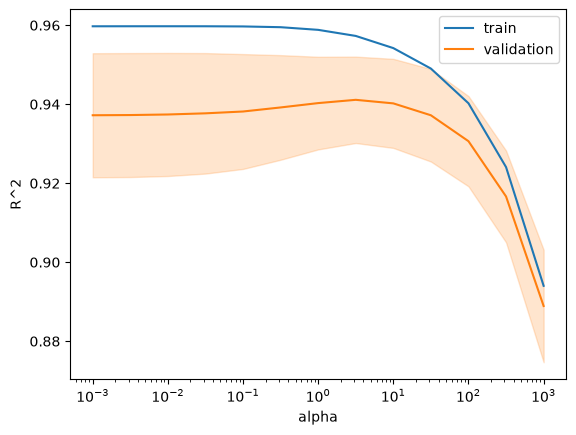

In [5]:
pipe = make_pipeline(preprocess, log_target(Ridge()))
param_grid = {'transformedtargetregressor__regressor__alpha': np.logspace(-3, 3, 13)}
grid = GridSearchCV(pipe, param_grid, cv=KFold(10, shuffle=True, random_state=SEED),
                    return_train_score=True, n_jobs=-1)
grid.fit(X_train, y_train)
print(grid.best_params_, round(grid.best_score_, 3))

res = pd.DataFrame(grid.cv_results_)
alphas = res['param_transformedtargetregressor__regressor__alpha'].astype(float)
plt.semilogx(alphas, res.mean_train_score, label='train')
plt.semilogx(alphas, res.mean_test_score, label='validation')
plt.fill_between(alphas, res.mean_test_score - res.std_test_score,
                 res.mean_test_score + res.std_test_score, alpha=.2, color='C1')
plt.xlabel('alpha'); plt.ylabel('R^2'); plt.legend();

`get_feature_names_out` works through the whole pipeline, so coefficients can be mapped back to (one-hot encoded) features. Remember that these are coefficients on the log scale: a coefficient of 0.1 means roughly a 10% change in price.

In [6]:
best = grid.best_estimator_
names = best[0].get_feature_names_out()
coef = pd.Series(best[-1].regressor_.coef_, index=names)
coef.reindex(coef.abs().sort_values(ascending=False).index).head(10)

pipeline__Overall_Qual_Poor             -0.231425
pipeline__Functional_Sal                -0.207892
pipeline__Overall_Qual_Very_Poor        -0.184714
pipeline__Exter_Cond_Poor               -0.160517
pipeline__Heating_QC_Poor               -0.152267
pipeline__Overall_Qual_Very_Excellent    0.151563
pipeline__Overall_Qual_Excellent         0.151123
pipeline__Overall_Cond_Poor             -0.145263
pipeline__MS_Zoning_A_agr               -0.123265
pipeline__Overall_Cond_Excellent         0.122275
dtype: float64

## Try it 1 (in class, ~15 min): a small Ames competition

The winner has the lowest **test RMSE in dollars**. Rules:

* linear models only (`LinearRegression`, `Ridge`, `Lasso`, `ElasticNet` or their `...CV` versions);
* any preprocessing you like (log target, `PolynomialFeatures` on a few numeric columns, `SplineTransformer`, dropping or adding features);
* choose everything with cross-validation on `X_train`; evaluate on `X_test` **once**, at the very end.

Question to discuss afterwards: why is it a mistake to try many variants on the test set and report the best?

In [7]:
# TODO: replace `my_model` with your best pipeline. Compare using CV on the training set only.
baseline = make_pipeline(preprocess, log_target(Ridge(alpha=3)))
my_model = baseline  # TODO: e.g. add SplineTransformer / PolynomialFeatures, try RidgeCV, LassoCV, ElasticNetCV

for name, model in [("baseline", baseline), ("my_model", my_model)]:
    cv_rmse = -cross_val_score(model, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    print(f"{name:10s} CV RMSE: ${cv_rmse.mean():,.0f}")

baseline   CV RMSE: $19,611
my_model   CV RMSE: $19,611


In [8]:
# Run this cell ONCE, at the end of the activity.
my_model.fit(X_train, y_train)
print(f"test RMSE: ${root_mean_squared_error(y_test, my_model.predict(X_test)):,.0f}")

test RMSE: $19,655


## 2. Regularization with few samples: triazines

A small QSAR (chemistry) dataset: 186 molecules, 60 descriptors. With only ~140 training samples for 60 features, plain least squares overfits badly.

In [9]:
triazines = fetch_openml('triazines', version=1, as_frame=True)
Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    triazines.data, triazines.target, random_state=0)
print("LinearRegression", cross_val_score(LinearRegression(), Xt_train, yt_train, cv=5).round(3))
print("Ridge()         ", cross_val_score(Ridge(), Xt_train, yt_train, cv=5).round(3))

LinearRegression [ 0.213  0.129 -0.796 -0.222 -0.155]
Ridge()          [0.263 0.455 0.024 0.23  0.036]


In [10]:
def nonzero(est, X, y):
    return np.sum(est.coef_ != 0)

lasso_grid = GridSearchCV(Lasso(max_iter=100_000), {'alpha': np.logspace(-5, 0, 10)}, cv=10,
                          scoring={'r2': 'r2', 'num_nonzero': nonzero}, refit='r2')
lasso_grid.fit(Xt_train, yt_train)
print(lasso_grid.best_params_, "CV R^2:", round(lasso_grid.best_score_, 3),
      "nonzero:", nonzero(lasso_grid.best_estimator_, None, None), "of", Xt_train.shape[1])

{'alpha': np.float64(0.0016681005372000592)} CV R^2: 0.163 nonzero: 13 of 60


In [11]:
enet_grid = GridSearchCV(ElasticNet(max_iter=100_000),
                         {'alpha': np.logspace(-4, -1, 10), 'l1_ratio': [.01, .1, .5, .9, 1]}, cv=10)
enet_grid.fit(Xt_train, yt_train)
print(enet_grid.best_params_, "CV R^2:", round(enet_grid.best_score_, 3))
pd.pivot_table(pd.DataFrame(enet_grid.cv_results_), values='mean_test_score',
               index='param_alpha', columns='param_l1_ratio').round(3)

{'alpha': np.float64(0.002154434690031882), 'l1_ratio': 0.5} CV R^2: 0.174


param_l1_ratio,0.01,0.10,0.50,0.90,1.00
param_alpha,,,,,
0.000100,-0.170,-0.159,-0.122,-0.088,-0.082
0.000215,-0.127,-0.111,-0.050,-0.006,0.005
0.000464,-0.071,-0.045,0.033,0.093,0.105
0.001000,-0.002,0.035,0.131,0.168,0.169
0.002154,0.069,0.106,0.174,0.160,0.158
0.004642,0.126,0.160,0.150,0.116,0.104
0.010000,0.153,0.149,0.073,-0.056,-0.067
0.021544,0.146,0.097,-0.072,-0.075,-0.075
0.046416,0.112,0.020,-0.075,-0.075,-0.075


**What goes wrong in practice.** The set of features Lasso selects is not stable. Refit the best Lasso on bootstrap resamples of the training data and count how often each feature is selected: many features come and go. Correlated features compete, and Lasso picks one of them more or less arbitrarily. Do not read "coefficient is zero" as "feature is irrelevant".

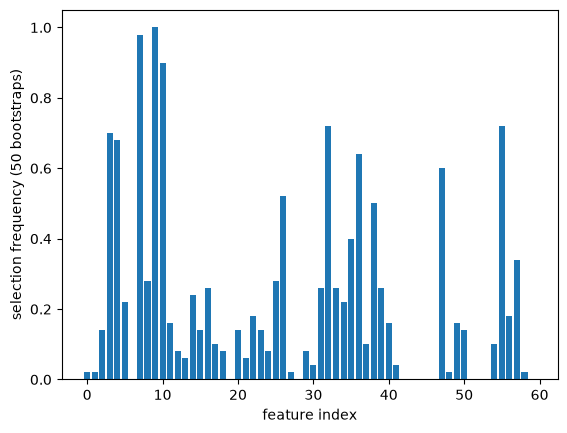

In [12]:
rng = np.random.RandomState(SEED)
alpha = lasso_grid.best_params_['alpha']
counts = np.zeros(Xt_train.shape[1])
for _ in range(50):
    idx = rng.randint(0, len(Xt_train), len(Xt_train))
    counts += Lasso(alpha=alpha, max_iter=100_000).fit(Xt_train.iloc[idx], yt_train.iloc[idx]).coef_ != 0
plt.bar(range(len(counts)), counts / 50)
plt.xlabel('feature index'); plt.ylabel('selection frequency (50 bootstraps)');

## 3. Logging a regularization path to MLflow

Each `alpha` for `Ridge` and `Lasso` becomes a child run with the cross-validated R^2 (mean and std) and the number of non-zero coefficients. The parent run stores the whole curve as a stepped metric and the plot as an artifact. Open the MLflow UI with `uv run mlflow ui` from the folder where the notebook ran and compare the child runs (the default local tracking store is git-ignored).

ridge: best alpha 3.162, CV R^2 0.115
lasso: best alpha 0.003162, CV R^2 0.130


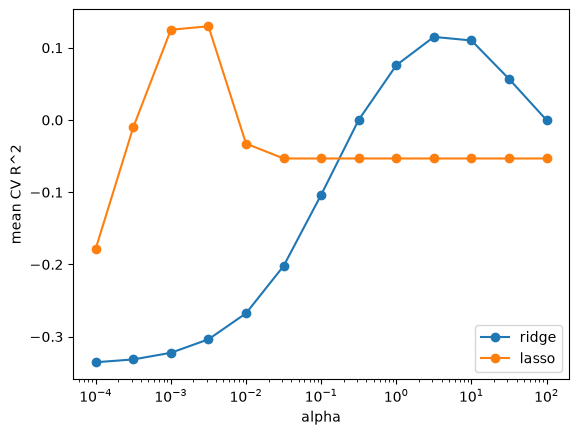

In [13]:
import mlflow

logging.getLogger("mlflow").setLevel(logging.WARNING)
mlflow.set_experiment("week04-linear-models")

cv = KFold(n_splits=10, shuffle=True, random_state=SEED)
path_alphas = np.logspace(-4, 2, 13)
curves = {}
with mlflow.start_run(run_name="regularization-path-triazines"):
    mlflow.log_params({"dataset": "triazines", "cv": "KFold(10, shuffle)", "n_train": len(Xt_train)})
    for name, make_model in [("ridge", lambda a: Ridge(alpha=a)),
                             ("lasso", lambda a: Lasso(alpha=a, max_iter=100_000))]:
        means = []
        for step, a in enumerate(path_alphas):
            scores = cross_val_score(make_model(a), Xt_train, yt_train, cv=cv)
            n_nonzero = int(np.sum(make_model(a).fit(Xt_train, yt_train).coef_ != 0))
            with mlflow.start_run(run_name=f"{name}-alpha={a:.4g}", nested=True):
                mlflow.log_params({"model": name, "alpha": a, "task": "triazines-path"})
                mlflow.log_metrics({"cv_r2_mean": scores.mean(), "cv_r2_std": scores.std(),
                                    "n_nonzero_coef": n_nonzero})
            mlflow.log_metric(f"{name}_cv_r2", scores.mean(), step=step)
            means.append(scores.mean())
        curves[name] = np.array(means)

    fig, ax = plt.subplots()
    for name, means in curves.items():
        ax.semilogx(path_alphas, means, 'o-', label=name)
    ax.set_xlabel("alpha"); ax.set_ylabel("mean CV R^2"); ax.legend()
    mlflow.log_figure(fig, "regularization_path.png")

for name, means in curves.items():
    print(f"{name}: best alpha {path_alphas[means.argmax()]:.4g}, CV R^2 {means.max():.3f}")

In [14]:
runs = mlflow.search_runs(experiment_names=["week04-linear-models"],
                          filter_string="params.task = 'triazines-path' and params.model = 'lasso'",
                          max_results=13)
runs[["params.alpha", "metrics.cv_r2_mean", "metrics.n_nonzero_coef"]]

,params.alpha,metrics.cv_r2_mean,metrics.n_nonzero_coef
0,100.0,-0.053300,0.0
1,31.622776601683793,-0.053300,0.0
2,10.0,-0.053300,0.0
3,3.1622776601683795,-0.053300,0.0
4,1.0,-0.053300,0.0
5,0.31622776601683794,-0.053300,0.0
6,0.1,-0.053300,0.0
7,0.03162277660168379,-0.053300,0.0
8,0.01,-0.032669,1.0
9,0.0031622776601683794,0.129815,8.0


## 4. Linear models for classification

Logistic regression and linear SVMs share the prediction rule `sign(w^T x + b)` and differ only in the loss (log loss vs. hinge loss). In scikit-learn both are regularized by `C`, the **inverse** of the regularization strength: small `C` means strong regularization.

In [15]:
X_bc, y_bc = load_breast_cancer(return_X_y=True, as_frame=True)
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bc, y_bc, stratify=y_bc, random_state=SEED)

for C in [0.001, 0.01, 0.1, 1, 10, 100]:
    logreg = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=5000))
    lsvm = make_pipeline(StandardScaler(), LinearSVC(C=C, max_iter=50_000))
    print(f"C={C:<6} logreg {cross_val_score(logreg, Xb_train, yb_train, cv=10).mean():.3f}   "
          f"linear SVM {cross_val_score(lsvm, Xb_train, yb_train, cv=10).mean():.3f}")

C=0.001  logreg 0.890   linear SVM 0.967
C=0.01   logreg 0.946   linear SVM 0.991


C=0.1    logreg 0.984   linear SVM 0.977
C=1      logreg 0.981   linear SVM 0.972
C=10     logreg 0.974   linear SVM 0.960


C=100    logreg 0.958   linear SVM 0.955


In [16]:
# probabilities: logistic regression gives them directly
logreg = make_pipeline(StandardScaler(), LogisticRegression()).fit(Xb_train, yb_train)
proba = logreg.predict_proba(Xb_test)[:5]
pd.DataFrame(proba, columns=['p(malignant)', 'p(benign)']).round(3)

,p(malignant),p(benign)
0,0.004,0.996
1,1.000,0.000
2,1.000,0.000
3,0.000,1.000
4,0.997,0.003


### Multiclass

`LogisticRegression` fits a multinomial (softmax) model with one coefficient vector per class. `LinearSVC` uses one-vs-rest, and kernel `SVC` uses one-vs-one internally.

In [17]:
iris = load_iris()
logreg = make_pipeline(StandardScaler(), LogisticRegression()).fit(iris.data, iris.target)
pd.DataFrame(logreg[-1].coef_, index=iris.target_names, columns=iris.feature_names).round(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
setosa,-1.08,1.16,-1.93,-1.81
versicolor,0.59,-0.36,-0.36,-0.83
virginica,0.49,-0.80,2.29,2.64


### Kernel SVMs on handwritten digits

The RBF kernel SVM has two parameters, `C` and `gamma`, which interact strongly. We scale the data and search both on a log grid. Note how `gamma` is expressed relative to `1 / n_features`, the natural scale after standardization.

{'svc__C': np.float64(10.0), 'svc__gamma': np.float64(0.0015625)} 0.982


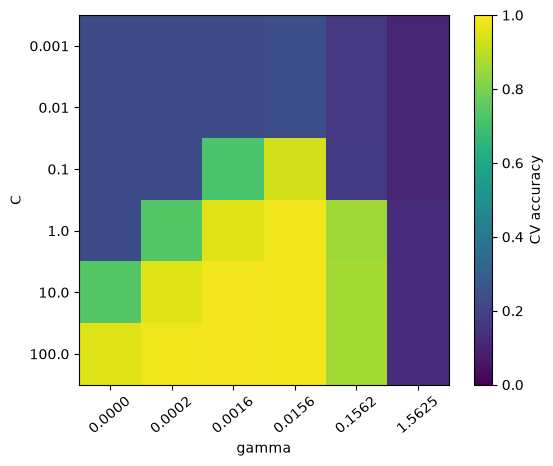

In [18]:
digits = load_digits()
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    digits.data, digits.target, stratify=digits.target, random_state=SEED)

scaled_svc = make_pipeline(StandardScaler(), SVC())
param_grid = {'svc__C': np.logspace(-3, 2, 6),
              'svc__gamma': np.logspace(-3, 2, 6) / Xd_train.shape[1]}
svc_grid = GridSearchCV(scaled_svc, param_grid, cv=5, n_jobs=-1).fit(Xd_train, yd_train)
print(svc_grid.best_params_, round(svc_grid.best_score_, 3))

scores = svc_grid.cv_results_['mean_test_score'].reshape(6, 6)
plt.imshow(scores, vmin=0, vmax=1)
plt.yticks(range(6), param_grid['svc__C']); plt.ylabel('C')
plt.xticks(range(6), [f"{g:.4f}" for g in param_grid['svc__gamma']], rotation=40); plt.xlabel('gamma')
plt.colorbar(label='CV accuracy');

## Try it 2 (in class, ~10 min): predict, then run

1. **Before running anything**, write down your ranking of these four models on the breast cancer training set (10-fold CV accuracy): logistic regression on raw features, logistic regression after `StandardScaler`, `SVC()` on raw features, `SVC()` after `StandardScaler`.
2. Run the cell. Which result surprised you, and why? (Hint: look at the ranges of the columns with `X_bc.describe()`.)
3. Tune `C` for the scaled logistic regression and look at its largest coefficients. Would you report them as "the features that cause malignancy"?

In [19]:
cv_bc = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
candidates = {
    "logreg raw": LogisticRegression(max_iter=10_000),
    "logreg scaled": make_pipeline(StandardScaler(), LogisticRegression()),
    "svc raw": SVC(),
    "svc scaled": make_pipeline(StandardScaler(), SVC()),
}
for name, model in candidates.items():
    print(f"{name:14s} {cross_val_score(model, Xb_train, yb_train, cv=cv_bc).mean():.3f}")

logreg raw     0.958
logreg scaled  0.979
svc raw        0.918
svc scaled     0.986


In [20]:
# TODO: (a) inspect the feature ranges, (b) tune C for the scaled logistic regression
# (e.g. LogisticRegressionCV(Cs=np.logspace(-3, 3, 13))) and print its largest coefficients.
X_bc.describe().loc[['min', 'max']].T.head()

,min,max
mean radius,6.98100,28.1100
mean texture,9.71000,39.2800
mean perimeter,43.79000,188.5000
mean area,143.50000,2501.0000
mean smoothness,0.05263,0.1634


## 5. Comparing linear and kernel classifiers with MLflow

Each model is a child run with its hyper-parameters, cross-validated accuracy and fit time. In the MLflow UI, select the child runs and use "Compare" to see accuracy against runtime.

In [21]:
mlflow.set_experiment("week04-linear-models")
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
models = {
    "logreg_C1": make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=5000)),
    "logreg_C0.01": make_pipeline(StandardScaler(), LogisticRegression(C=0.01, max_iter=5000)),
    "linear_svc_C1": make_pipeline(StandardScaler(), LinearSVC(C=1)),
    "svc_rbf_default": make_pipeline(StandardScaler(), SVC()),
    "svc_rbf_tuned": make_pipeline(StandardScaler(), SVC(C=svc_grid.best_params_['svc__C'],
                                                         gamma=svc_grid.best_params_['svc__gamma'])),
}
with mlflow.start_run(run_name="digits-linear-vs-kernel"):
    mlflow.log_params({"dataset": "digits", "cv": "StratifiedKFold(10, shuffle)",
                       "n_train": len(Xd_train)})
    for name, model in models.items():
        tick = time()
        scores = cross_val_score(model, Xd_train, yd_train, cv=cv)
        with mlflow.start_run(run_name=name, nested=True):
            mlflow.log_params({"model": name, "task": "digits-classification"})
            mlflow.log_params({k: v for k, v in model[-1].get_params().items() if k in ("C", "gamma")})
            mlflow.log_metrics({"cv_accuracy_mean": scores.mean(), "cv_accuracy_std": scores.std(),
                                "cv_seconds": time() - tick})
        print(f"{name:16s} {scores.mean():.3f} +/- {scores.std():.3f}")

logreg_C1        0.973 +/- 0.013


logreg_C0.01     0.943 +/- 0.015


linear_svc_C1    0.957 +/- 0.020
svc_rbf_default  0.980 +/- 0.011


svc_rbf_tuned    0.982 +/- 0.007


In [22]:
runs = mlflow.search_runs(experiment_names=["week04-linear-models"],
                          filter_string="params.task = 'digits-classification'", max_results=5)
runs[["params.model", "metrics.cv_accuracy_mean", "metrics.cv_accuracy_std", "metrics.cv_seconds"]]

,params.model,metrics.cv_accuracy_mean,metrics.cv_accuracy_std,metrics.cv_seconds
0,svc_rbf_tuned,0.982178,0.006830,0.137377
1,svc_rbf_default,0.979934,0.011092,0.197066
2,linear_svc_C1,0.956888,0.020029,1.391316
3,logreg_C0.01,0.942830,0.014904,0.053802
4,logreg_C1,0.973239,0.013456,0.073359


## Further practice (optional)

* Replace `SVC` with `make_pipeline(Nystroem(n_components=300), LogisticRegression())` from `sklearn.kernel_approximation` on the digits data. How close do you get to the kernel SVM, and how much faster is it on 10x more data?
* On Ames, compare `LassoCV` and `RidgeCV` inside the log-target pipeline and log both to MLflow.